##### Imports

In [133]:
import torch
import torch.nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

###### Dataset Image Transformations

In [134]:
# Define transformations for the dataset
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.465,0.406],std=[0.229,0.224,0.225])
    ]
)

###### Loading the dataset

In [135]:
dataset_dir = 'alexnet-dataset'
train_dataset = torchvision.datasets.ImageFolder(root=dataset_dir + '/train',transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root=dataset_dir+'/test',transform=transform)

###### Create DataLoaders

In [136]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)


###### Dataset info

In [137]:
# Get dataset information
def dataset_info(loader,dataset_name='Dataset'):
    print(f'Dataset: {dataset_name}')
    print(f'Total Samples: {len(loader.dataset)}') # total number of images

    # Get a single batch of data
    images,labels = next(iter(loader))
    print(f'Batch Size: {images.shape[0]}')
    print(f'Image Shape: {images.shape}')
    print(f'Unique Classes {set(labels.numpy())}')
    print(f'Total classes: {len(set(labels.numpy()))}')


dataset_info(train_loader,'Training Set')


Dataset: Training Set
Total Samples: 1275
Batch Size: 32
Image Shape: torch.Size([32, 3, 224, 224])
Unique Classes {np.int64(0), np.int64(1)}
Total classes: 2


##### Model Training

In [138]:
def train(num_epochs=10):
    train_losses,train_accuracies = [],[]
    for epoch in range(num_epochs):
        model.train()
        running_loss,correct,total = 0.0,0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss+=loss.item()
            _,predicted = outputs.max(1)
            total+= labels.size(0)
            correct += predicted.eq(labels).sum().item()
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}')
    return train_losses,train_accuracies


##### Model Architecture

In [139]:
import torch.nn as nn

In [140]:
class AlexNet(nn.Module):
    def __init__(self,num_classes=2):
        super(AlexNet,self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,64,kernel_size=11,stride=4,padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3,stride=2),
            nn.Conv2d(64,192,kernel_size=5,padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3,stride=2),
            nn.Conv2d(192,384,kernel_size=3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384,256,kernel_size=3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3,stride=2)

        )
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256*6*6,4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096,4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096,num_classes)
        )
    
    def forward(self,x):
        x=self.features(x)
        x=torch.flatten(x,1)
        x=self.classifier(x)
        return x
        

##### Model, Loss Function and Optimizer

In [141]:
# Instantiate model,loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AlexNet(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

#### Model Evaluation

In [142]:
# Evaluate function
def evaluate():
    model.eval()
    correct,total = 0,0
    with torch.no_grad():
        for images,labels in test_loader:
            images,labels = images.to(device),labels.to(device)
            outputs = model(images)
            _,predictions = outputs.max(1)
            total+=labels.size(0)
            correct += predictions.eq(labels).sum().item()
    accuracy = 100. * correct / total
    print(f'Test Accuracy: {accuracy:.2f}')
    return accuracy

#### Model Inferencing

In [143]:
# Inference Function
def predict_image(image_path):
    from PIL import Image
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(image)
        _,predicted = output.max(1)
    
    print(f'Predicted Class: {predicted.item()}')
    return predicted.item()


#### Visualization of loss and accuracy

In [144]:
def plot_metrics(train_losses,train_accuracies):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses,label= 'Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(train_accuracies,label='Train Accuracy',color='green')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

##################################################
Training Started
Epoch 1, Loss: 1.0255, Accuracy: 59.53
Epoch 2, Loss: 0.6238, Accuracy: 66.04
Epoch 3, Loss: 0.5349, Accuracy: 72.24
Epoch 4, Loss: 0.4786, Accuracy: 77.96
Epoch 5, Loss: 0.4266, Accuracy: 81.33
Training Completed
##################################################
Model Evaluation Started
Test Accuracy: 82.42
Model Evaluation Completed
##################################################
Plotting the metrics


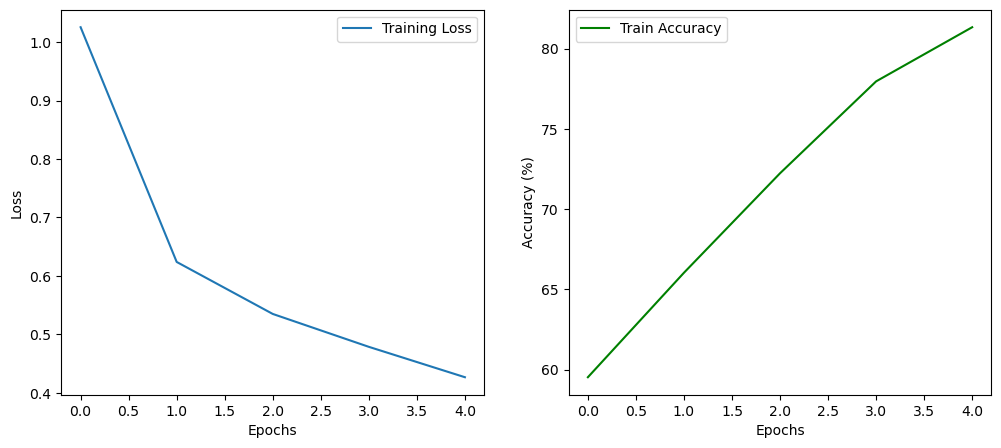

In [145]:
# Run training,evaluation and plot results
print('#'*50)
print("Training Started")
train_losses,train_accuracies = train(num_epochs=5)
print('Training Completed')
print('#'*50)
print("Model Evaluation Started")
evaluate()
print('Model Evaluation Completed')
print('#'*50)
print('Plotting the metrics')
plot_metrics(train_losses,train_accuracies)

In [147]:
predict_image('alexnet-dataset/test/daisy/1354396826_2868631432_m_jpg.rf.409eee37613d16dbc71365cb5615327e.jpg')

Predicted Class: 0


0

In [148]:
predict_image('alexnet-dataset/test/dandelion/2392273474_a64cef0eaf_n_jpg.rf.3705fdaf3d656cbc2bf8997ffaceb28e.jpg')

Predicted Class: 1


1